# Challenge Telecom X

# Generar la data

In [ ]:
import pandas as pd

file = 'TelecomX_Data.json'

df = pd.read_json(file)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [8]:
cols_normalize = ['customer','phone','internet','account']

for col in cols_normalize:
    df = df.join(
        pd.json_normalize(df.pop(col)).add_prefix(f"{col}_")
    )

df.head()


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   str    
 1   Churn                      7267 non-null   str    
 2   customer_gender            7267 non-null   str    
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   str    
 5   customer_Dependents        7267 non-null   str    
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   str    
 8   phone_MultipleLines        7267 non-null   str    
 9   internet_InternetService   7267 non-null   str    
 10  internet_OnlineSecurity    7267 non-null   str    
 11  internet_OnlineBackup      7267 non-null   str    
 12  internet_DeviceProtection  7267 non-null   str    
 13  internet_TechSupport       7267 non-null   str    
 14  int

Existe error en Total, hay un string.

## Checar inconsistencias

In [10]:
columnas_titles = df.columns
columnas_titles

Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges.Monthly', 'account_Charges.Total'],
      dtype='str')

In [13]:
for col in columnas_titles:
    print(f"\nColumna: {col}")
    print(df[col].unique())


Columna: customerID
<StringArray>
['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF', '0013-EXCHZ',
 '0013-MHZWF', '0013-SMEOE', '0014-BMAQU', '0015-UOCOJ', '0016-QLJIS',
 ...
 '9975-SKRNR', '9978-HYCIN', '9979-RGMZT', '9985-MWVIX', '9986-BONCE',
 '9987-LUTYD', '9992-RRAMN', '9992-UJOEL', '9993-LHIEB', '9995-HOTOH']
Length: 7267, dtype: str

Columna: Churn
<StringArray>
['No', 'Yes', '']
Length: 3, dtype: str

Columna: customer_gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

Columna: customer_SeniorCitizen
[0 1]

Columna: customer_Partner
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Columna: customer_Dependents
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Columna: customer_tenure
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]

Columna: phone_PhoneService
<StringArray>
['Yes', 'No

Hay un string vacio en Churn

## Arreglar inconsistencias
1. String vacio en Churn.
2. La columna total a float.

### String vacio

In [15]:
df['Churn'].value_counts(dropna=False)

Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

Debido a que son pocos clientes. Procedemos a eliminar

In [16]:
df = df[df['Churn'].str.strip() != '']
df['Churn'].value_counts(dropna=False)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

### Columna de total a float

In [17]:
df['account_Charges.Total'] = pd.to_numeric(df['account_Charges.Total'], errors='coerce')
df.info()

<class 'pandas.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   str    
 1   Churn                      7043 non-null   str    
 2   customer_gender            7043 non-null   str    
 3   customer_SeniorCitizen     7043 non-null   int64  
 4   customer_Partner           7043 non-null   str    
 5   customer_Dependents        7043 non-null   str    
 6   customer_tenure            7043 non-null   int64  
 7   phone_PhoneService         7043 non-null   str    
 8   phone_MultipleLines        7043 non-null   str    
 9   internet_InternetService   7043 non-null   str    
 10  internet_OnlineSecurity    7043 non-null   str    
 11  internet_OnlineBackup      7043 non-null   str    
 12  internet_DeviceProtection  7043 non-null   str    
 13  internet_TechSupport       7043 non-null   str    
 14  internet

In [18]:
df.isnull().sum()

customerID                    0
Churn                         0
customer_gender               0
customer_SeniorCitizen        0
customer_Partner              0
customer_Dependents           0
customer_tenure               0
phone_PhoneService            0
phone_MultipleLines           0
internet_InternetService      0
internet_OnlineSecurity       0
internet_OnlineBackup         0
internet_DeviceProtection     0
internet_TechSupport          0
internet_StreamingTV          0
internet_StreamingMovies      0
account_Contract              0
account_PaperlessBilling      0
account_PaymentMethod         0
account_Charges.Monthly       0
account_Charges.Total        11
dtype: int64

Hay valores nulos en la conversion, analizamos el numero de clientes que llevan 0 meses.

In [19]:
df['customer_tenure'].value_counts(dropna=False)

customer_tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64

Existe la misma cantidad que clientes que llevan 0 dias. Si coincide el total con el tenure, entonces los dejamos en 0.

In [23]:
df.loc[(df['account_Charges.Total'].isna()) & (df['customer_tenure'] == 0),'account_Charges.Total'] = 0
df.info()

<class 'pandas.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   str    
 1   Churn                      7043 non-null   str    
 2   customer_gender            7043 non-null   str    
 3   customer_SeniorCitizen     7043 non-null   int64  
 4   customer_Partner           7043 non-null   str    
 5   customer_Dependents        7043 non-null   str    
 6   customer_tenure            7043 non-null   int64  
 7   phone_PhoneService         7043 non-null   str    
 8   phone_MultipleLines        7043 non-null   str    
 9   internet_InternetService   7043 non-null   str    
 10  internet_OnlineSecurity    7043 non-null   str    
 11  internet_OnlineBackup      7043 non-null   str    
 12  internet_DeviceProtection  7043 non-null   str    
 13  internet_TechSupport       7043 non-null   str    
 14  internet

In [24]:
df.isnull().sum()

customerID                   0
Churn                        0
customer_gender              0
customer_SeniorCitizen       0
customer_Partner             0
customer_Dependents          0
customer_tenure              0
phone_PhoneService           0
phone_MultipleLines          0
internet_InternetService     0
internet_OnlineSecurity      0
internet_OnlineBackup        0
internet_DeviceProtection    0
internet_TechSupport         0
internet_StreamingTV         0
internet_StreamingMovies     0
account_Contract             0
account_PaperlessBilling     0
account_PaymentMethod        0
account_Charges.Monthly      0
account_Charges.Total        0
dtype: int64

Arreglado

In [26]:
df['cuentas_diarias'] = df['account_Charges.Monthly']/30
df.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges.Monthly,account_Charges.Total,cuentas_diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


## Estandarizacion

### Nombres

In [27]:
df.columns = (
        df.columns
        .str.replace(r'^(customer_|phone_|internet_|account_)', '', regex=True)
        .str.replace('.', '_', regex=False)
        .str.lower()
    )

df.info()

<class 'pandas.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   str    
 1   churn             7043 non-null   str    
 2   gender            7043 non-null   str    
 3   seniorcitizen     7043 non-null   int64  
 4   partner           7043 non-null   str    
 5   dependents        7043 non-null   str    
 6   tenure            7043 non-null   int64  
 7   phoneservice      7043 non-null   str    
 8   multiplelines     7043 non-null   str    
 9   internetservice   7043 non-null   str    
 10  onlinesecurity    7043 non-null   str    
 11  onlinebackup      7043 non-null   str    
 12  deviceprotection  7043 non-null   str    
 13  techsupport       7043 non-null   str    
 14  streamingtv       7043 non-null   str    
 15  streamingmovies   7043 non-null   str    
 16  contract          7043 non-null   str    
 17  paperlessbi

## Análisis descriptivo

Describe method:

In [28]:
df.describe()

,seniorcitizen,tenure,charges_monthly,charges_total,cuentas_diarias
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,2.158723
std,0.368612,24.559481,30.090047,2266.794470,1.003002
min,0.000000,0.000000,18.250000,0.000000,0.608333
25%,0.000000,9.000000,35.500000,398.550000,1.183333
50%,0.000000,29.000000,70.350000,1394.550000,2.345000
75%,0.000000,55.000000,89.850000,3786.600000,2.995000
max,1.000000,72.000000,118.750000,8684.800000,3.958333


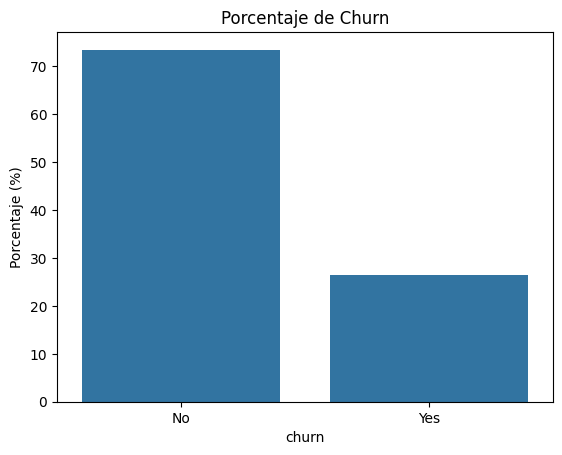

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

porcentaje_churn = df['churn'].value_counts(normalize=True) * 100

sns.barplot(x=porcentaje_churn.index, y=porcentaje_churn.values)
plt.ylabel('Porcentaje (%)')
plt.title('Porcentaje de Churn')
plt.show()

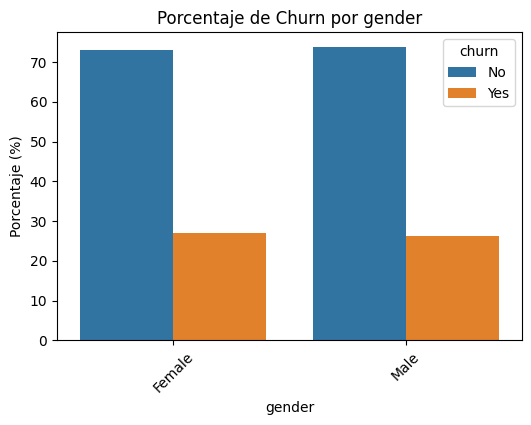

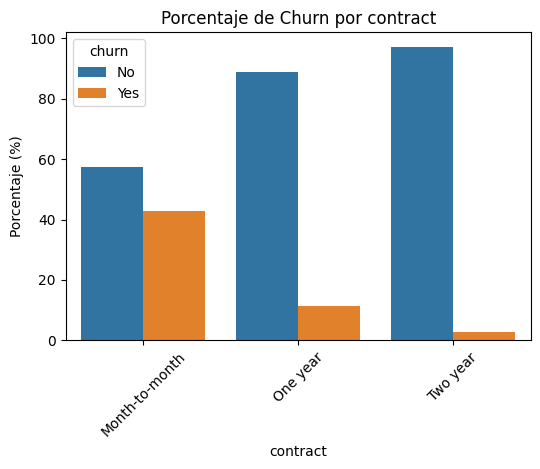

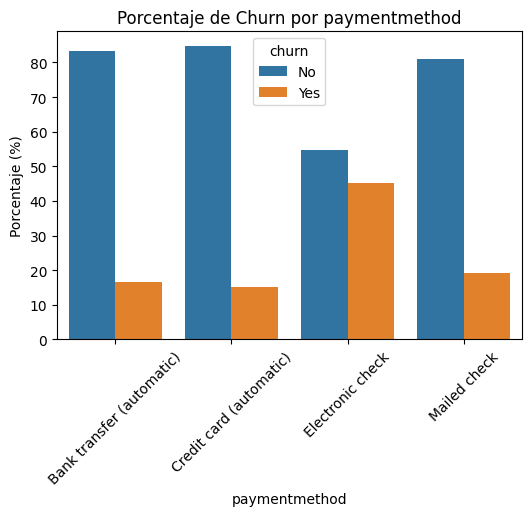

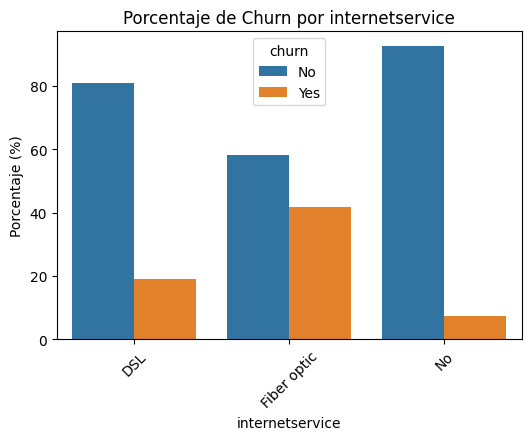

In [38]:
categorical_cols = [
    'gender',
    'contract',
    'paymentmethod',
    'internetservice'
]

for col in categorical_cols:
    
    # Calcular porcentaje por categoría
    porcentaje = (
        pd.crosstab(df[col], df['churn'], normalize='index') * 100
    ).reset_index()
    
    # Convertir a formato largo
    porcentaje_melt = porcentaje.melt(id_vars=col, 
                                       var_name='churn', 
                                       value_name='percent')
    
    plt.figure(figsize=(6,4))
    sns.barplot(data=porcentaje_melt, x=col, y='percent', hue='churn')
    
    plt.ylabel('Porcentaje (%)')
    plt.title(f'Porcentaje de Churn por {col}')
    plt.xticks(rotation=45)
    plt.show()

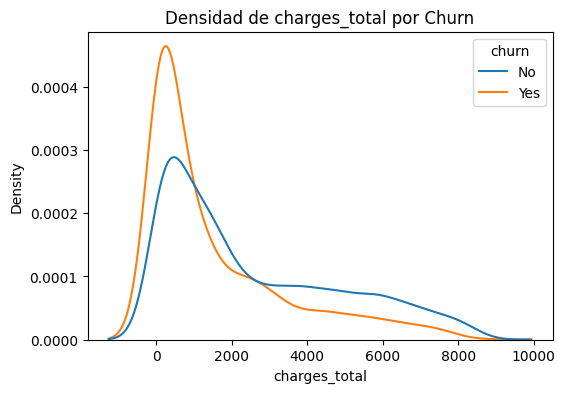

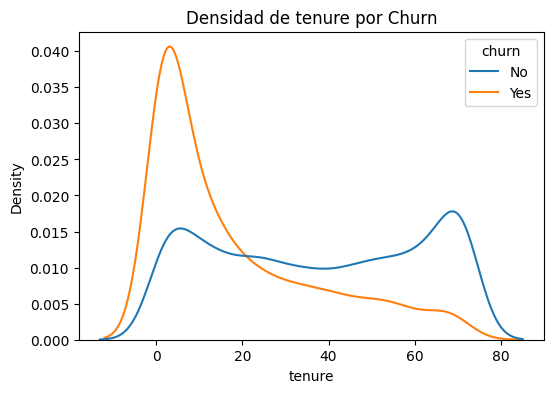

In [36]:
numerical_cols = ['charges_total', 'tenure']

for col in numerical_cols:
    plt.figure(figsize=(6,4))
    
    sns.kdeplot(
        data=df,
        x=col,
        hue='churn',
        common_norm=False
    )
    
    plt.title(f'Densidad de {col} por Churn')
    plt.show()

## Informe Final

### Introduccion

La evasión de clientes es una de los mayores problemas para las empresas manejadas por suscripción. Todos quieren ganar clientes y mantenerlos de por vida, por lo tanto, que los clientes renuncien a la suscripción no resulta positivo para las empresas. Debido a los comentarios previos, el objetivo es:

- Explorar los factores asociados a la cancelación del servicio.
- Identificar los posibles patrones.
- Detectar perfiles de clientes con mayor probabilidad de evasión.
- Proponer acciones estratégicas para resolverlo.


### Limpieza y tratamiento de datos

Durante la preparación, se realizó:
1. Importación y revisión inicial:
    Carga del conjunto de datos.
    Verificar dimensiones y tipo de datos.
    Columnas categóricas y numéricas.
2. Limpieza de datos:
    Adiós blank spaces.
    String vaciós fueron eliminados.
    Se convirtieron los resultados totales de string a float.
    Se corrigieron valores inconsistentes.
3. Análisis exploratorio de datos
    - Distribución general de la evasión
        Se observó que alrededor del 30% de los clientes cancelaron el servicio.
        Alrededor del 70% siguen activos.
    Los detalles se muestran en la siguiente figura.

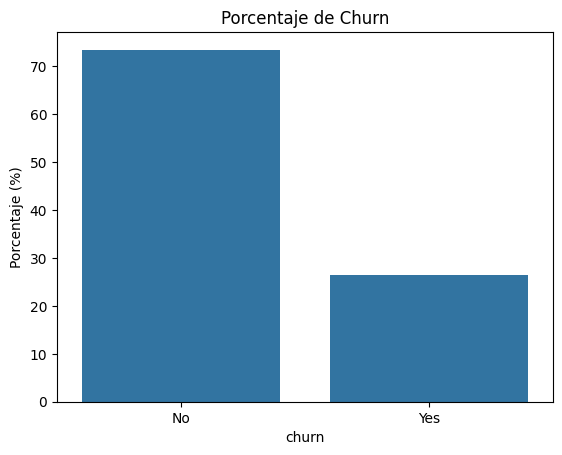

In [39]:
sns.barplot(x=porcentaje_churn.index, y=porcentaje_churn.values)
plt.ylabel('Porcentaje (%)')
plt.title('Porcentaje de Churn')
plt.show()

    - Se analizaron distintos rangos categoricos en contra de la evasión tales como:
        Género
        Tipo de contrato
        Método de pago
        Servicios adicionales
    - Se encontró que el género no influye en la decisión del mercado.
    - Los clientes con un contrato de mes a mes presentan una mayor tasa de evasión.
    - Los clientes con electronic check tienen una mayor evasión.
    - Los clientes con fibra óptica tienen una mayor evasión. Lo cual hace pensar que son nuevos consumidores.
    Los resultados se muestran en la figura siguiente.

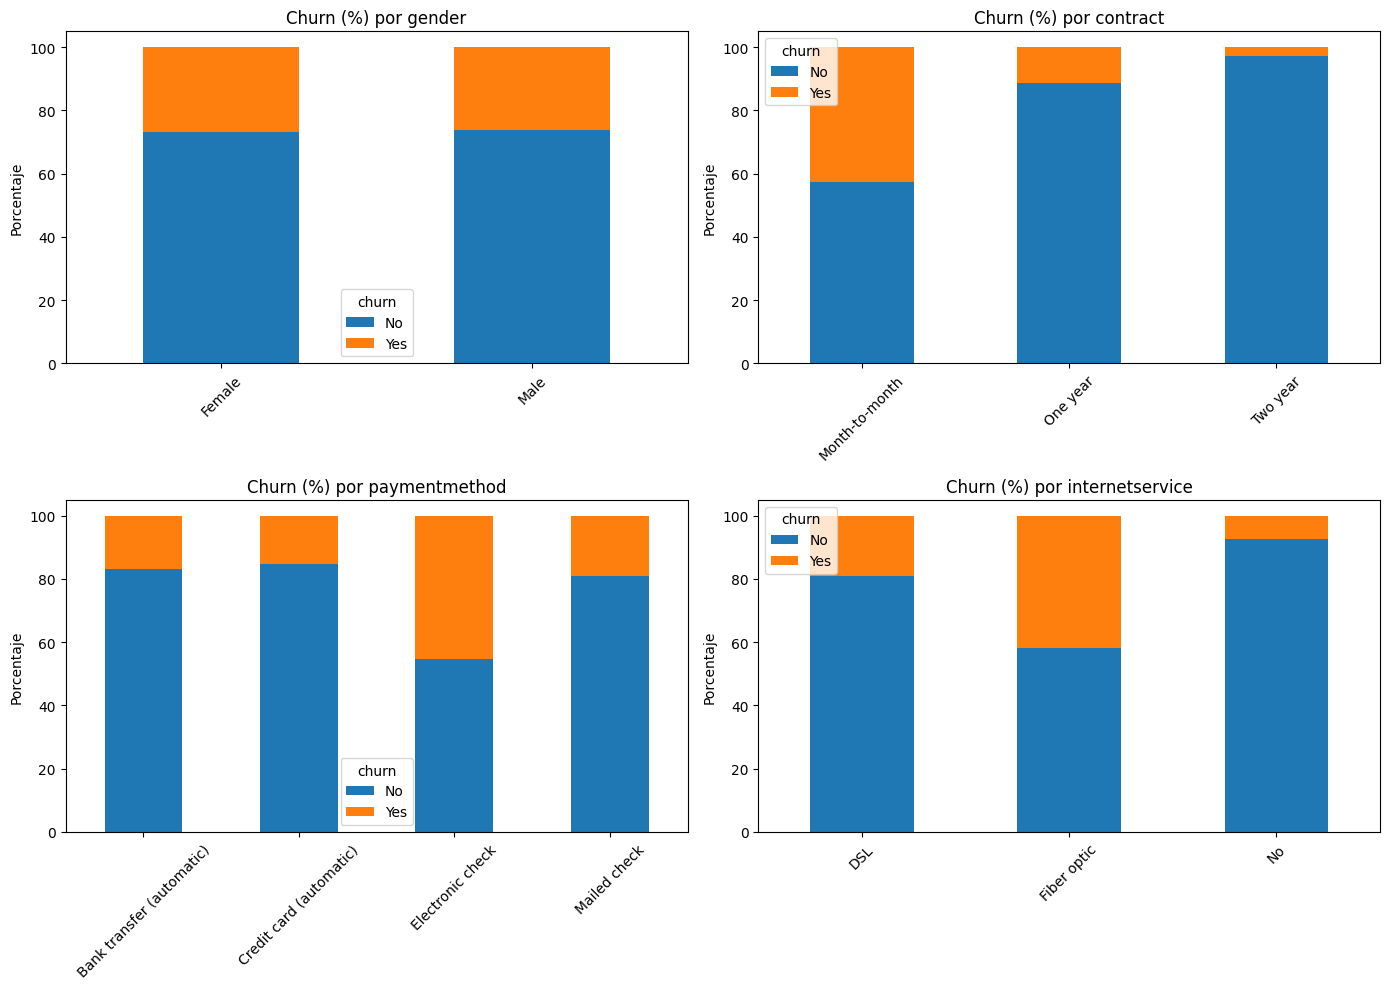

In [40]:
categorical_cols = [
    'gender',
    'contract',
    'paymentmethod',
    'internetservice'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    
    # Tabla porcentual
    tabla = (
        pd.crosstab(df[col], df['churn'], normalize='index') * 100
    )
    
    # Graficar apilado
    tabla.plot(
        kind='bar',
        stacked=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f'Churn (%) por {col}')
    axes[i].set_ylabel('Porcentaje')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

    - Se analizaron distintas variables numericas contra la evasión, tales como:
        Tiempo de Contrato
        Cargos mensuales
        Total gastado
    - Se encontró que los clientes con bajo tenure presentan mayor riesgo de evasión.
    - De la misma manera, las personas humildes tienen mayor riesgo de evasión.
    La información se encuentra en la sig. figura:

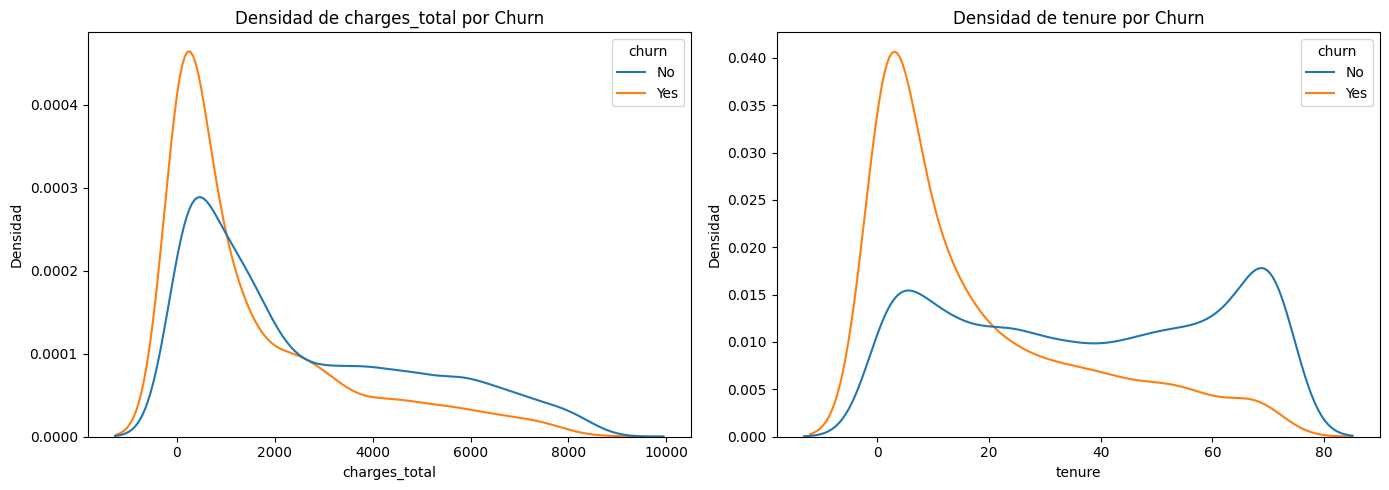

In [41]:
numerical_cols = ['charges_total', 'tenure']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(numerical_cols):
    
    sns.kdeplot(
        data=df,
        x=col,
        hue='churn',
        common_norm=False,
        ax=axes[i]
    )
    
    axes[i].set_title(f'Densidad de {col} por Churn')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Densidad')

plt.tight_layout()
plt.show()

### Conclusiones

1. La duración del contrato es importante: Contratos cortos presentan mayor evasión.
2. El método de pago influye, siendo el factor de mayor peligro.
3. Clientes nuevos son aquellos que mayormente huyen.
4. Servicios complementarios reducen la probabilidad de cancelación.


### Recomendaciones estratégicas
1. Incentivar contratos de mayor duración.
2. Programas de retención a los primeros meses con oferta o soporte adicional.
3. Promocionar servicios complementarios.
4. Optimizar métodos de pago.